In [1]:

# Dataset Used: California Housing Prices
# Kaggle Link: https://www.kaggle.com/datasets/camnugent/california-housing-prices


## 1. Install and import required libraries




In [21]:
import sys
import subprocess

required = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "xgboost"]

for package in required:
    try:
        __import__(package if package != "scikit-learn" else "sklearn")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
np.random.seed(42)

## 2. Load the data

In [4]:
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Explore the data (EDA)

Here we look at the columns, data types, missing values, and basic statistics.

In [22]:

print("Dataset Info")
df.info()

print("\n" + "=" * 60)
print("Missing Values per Column")

print(df.isnull().sum())

print("Duplicated rows:", df.duplicated().sum())

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Missing Values per Column
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
med

In [6]:
print("Statistical Summary (Numerical Columns):")
df.describe().T

Statistical Summary (Numerical Columns):


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [7]:
print("Categorical Column 'ocean_proximity' value counts:")
df["ocean_proximity"].value_counts()

Categorical Column 'ocean_proximity' value counts:


,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


### Distribution of the target variable `median_house_value`

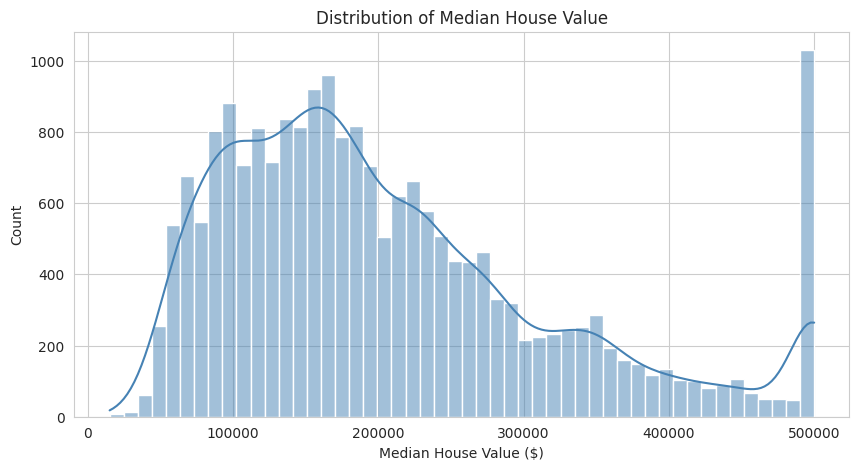

Skewness: 0.9777632739098341


In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df["median_house_value"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($)")
plt.ylabel("Count")
plt.show()

print("Skewness:", df["median_house_value"].skew())

### Distribution of the other numerical variables

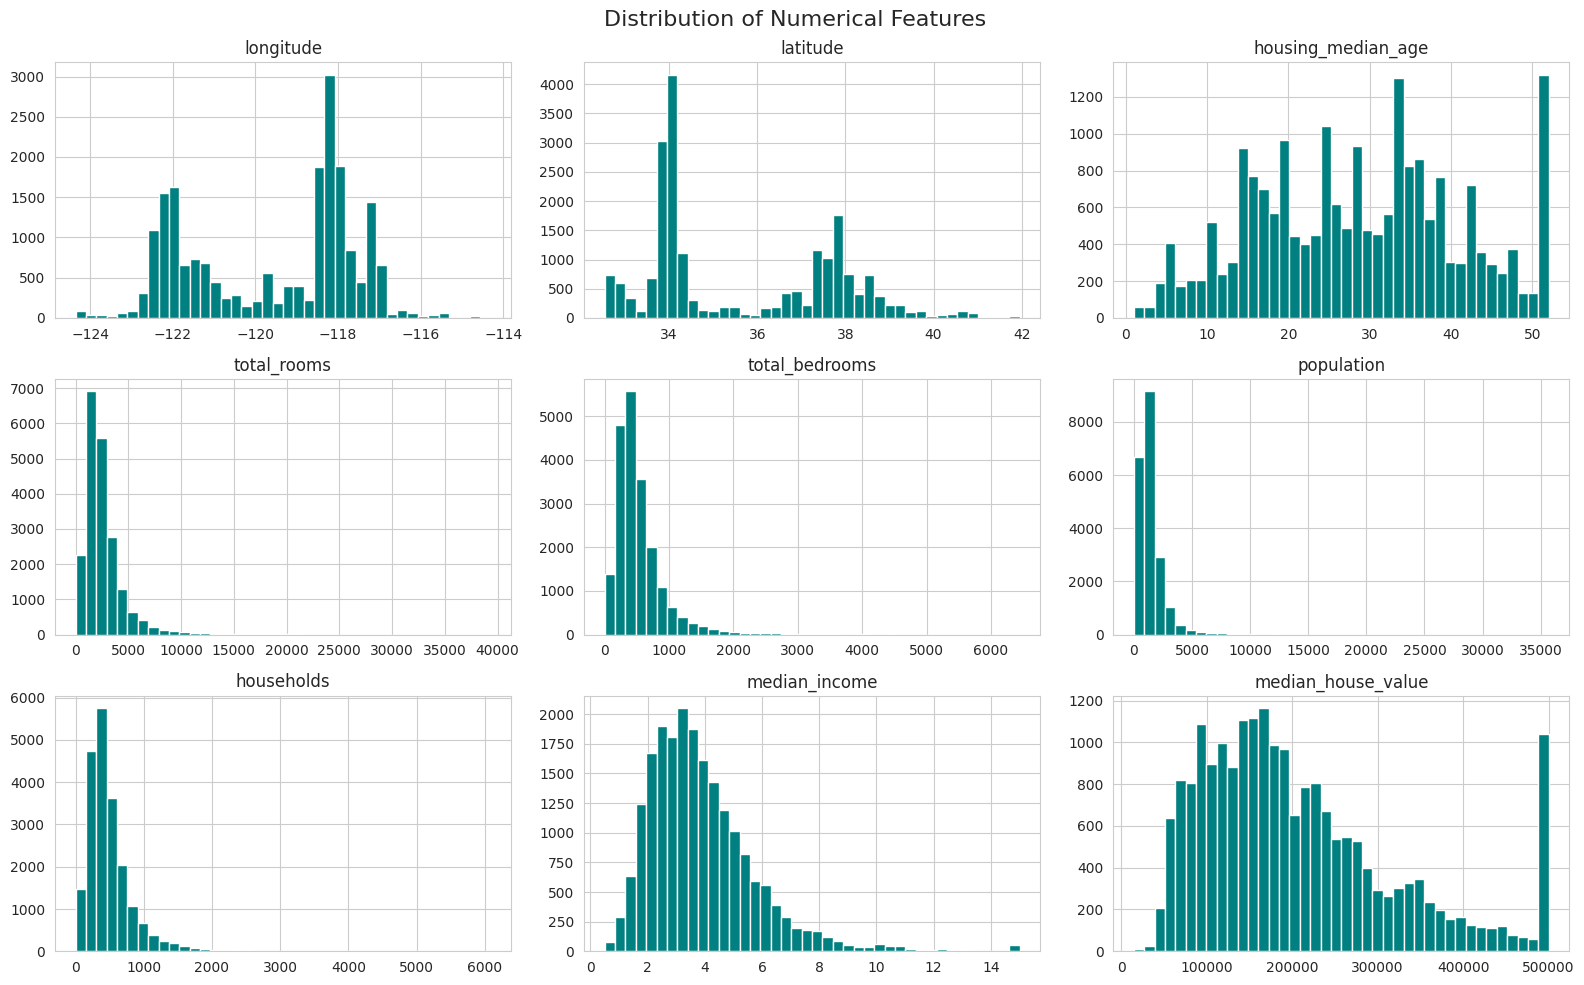

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols].hist(bins=40, figsize=(16, 10), color="teal")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Correlation between variables

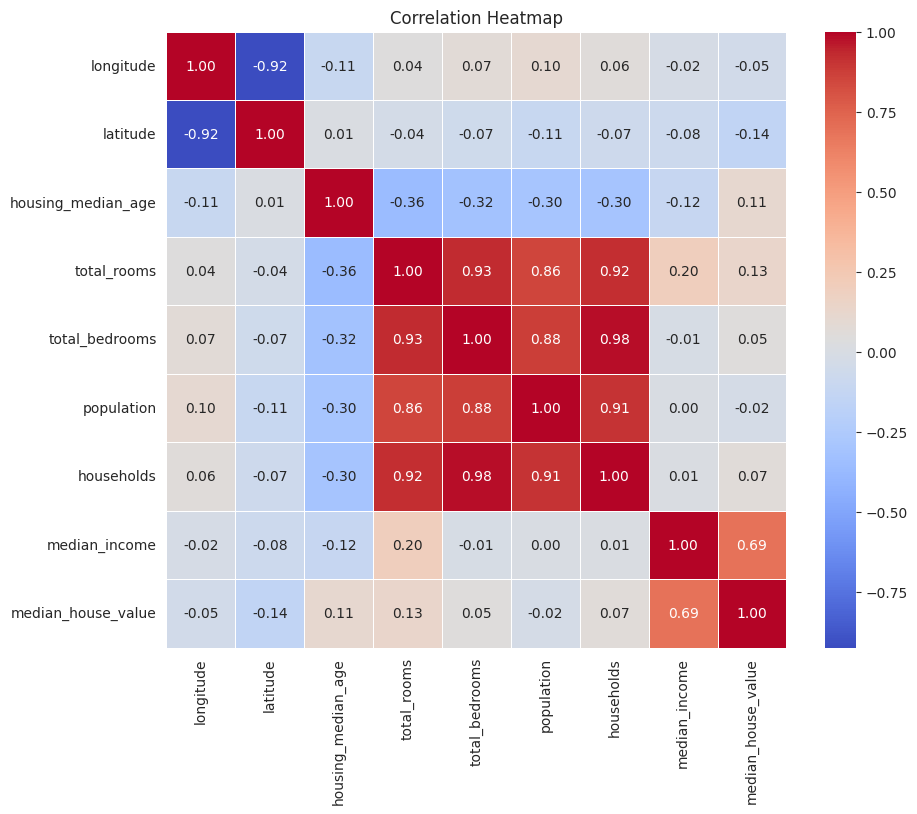


Correlation with target (median_house_value):
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [10]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with target (median_house_value):")
print(corr["median_house_value"].sort_values(ascending=False))

### Geographic relationship between location and price

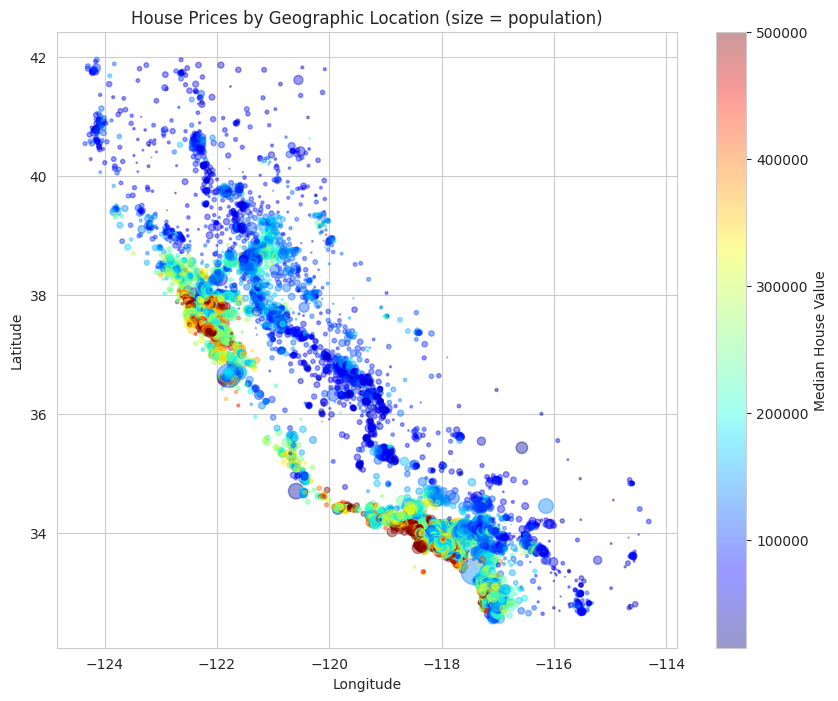

In [11]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(df["longitude"], df["latitude"], c=df["median_house_value"],
                  cmap="jet", alpha=0.4, s=df["population"] / 100)
plt.colorbar(sc, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Prices by Geographic Location (size = population)")
plt.show()

## 4. Clean the data and engineer features


- Fill missing values in `total_bedrooms` using the median
- Create new useful features: `rooms_per_household`, `bedrooms_per_room`, `population_per_household`
- Convert the categorical column `ocean_proximity` using One-Hot Encoding

In [12]:
data = df.copy()

# Handle missing values
data["total_bedrooms"] = data["total_bedrooms"].fillna(data["total_bedrooms"].median())

# Feature Engineering
data["rooms_per_household"] = data["total_rooms"] / data["households"]
data["bedrooms_per_room"] = data["total_bedrooms"] / data["total_rooms"]
data["population_per_household"] = data["population"] / data["households"]

# One-Hot Encoding for categorical column
data = pd.get_dummies(data, columns=["ocean_proximity"], drop_first=True)

print("Shape after cleaning and feature engineering:", data.shape)
data.head()

Shape after cleaning and feature engineering: (20640, 16)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


## 5. Train/test split and scaling

In [13]:
X = data.drop("median_house_value", axis=1)
y = data["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 15)
Test shape: (4128, 15)


## 6. Compare several regression models

We try a set of different models using 5-Fold Cross Validation and compare
them using RMSE, in order to pick the best model before tuning.

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Lasso Regression": Lasso(alpha=0.1, random_state=42),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=200, n_jobs=-1, verbosity=0),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    rmse_scores = -cross_val_score(model, X_train_scaled, y_train,
                                    scoring="neg_root_mean_squared_error", cv=kf, n_jobs=-1)
    r2_scores = cross_val_score(model, X_train_scaled, y_train,
                                 scoring="r2", cv=kf, n_jobs=-1)
    results.append({
        "Model": name,
        "RMSE (mean)": rmse_scores.mean(),
        "RMSE (std)": rmse_scores.std(),
        "R2 (mean)": r2_scores.mean()
    })
    print(f"{name:<20} -> RMSE: {rmse_scores.mean():,.0f} | R2: {r2_scores.mean():.4f}")

results_df = pd.DataFrame(results).sort_values("RMSE (mean)").reset_index(drop=True)
results_df

Linear Regression    -> RMSE: 67,859 | R2: 0.6552
Ridge Regression     -> RMSE: 67,858 | R2: 0.6552
Lasso Regression     -> RMSE: 67,859 | R2: 0.6552
KNN Regressor        -> RMSE: 61,104 | R2: 0.7205
Decision Tree        -> RMSE: 62,226 | R2: 0.7103
Random Forest        -> RMSE: 50,262 | R2: 0.8110
Gradient Boosting    -> RMSE: 52,816 | R2: 0.7912
XGBoost              -> RMSE: 47,439 | R2: 0.8316


,Model,RMSE (mean),RMSE (std),R2 (mean)
0,XGBoost,47438.836591,756.571520,0.831622
1,Random Forest,50261.757498,1016.718425,0.810970
2,Gradient Boosting,52815.531072,999.617525,0.791250
3,KNN Regressor,61103.740608,997.033389,0.720481
4,Decision Tree,62225.833350,1080.432857,0.710258
5,Ridge Regression,67857.927324,1311.217791,0.655246
6,Lasso Regression,67858.745746,1312.144205,0.655237
7,Linear Regression,67858.778522,1312.172288,0.655237


### Visual comparison of the models

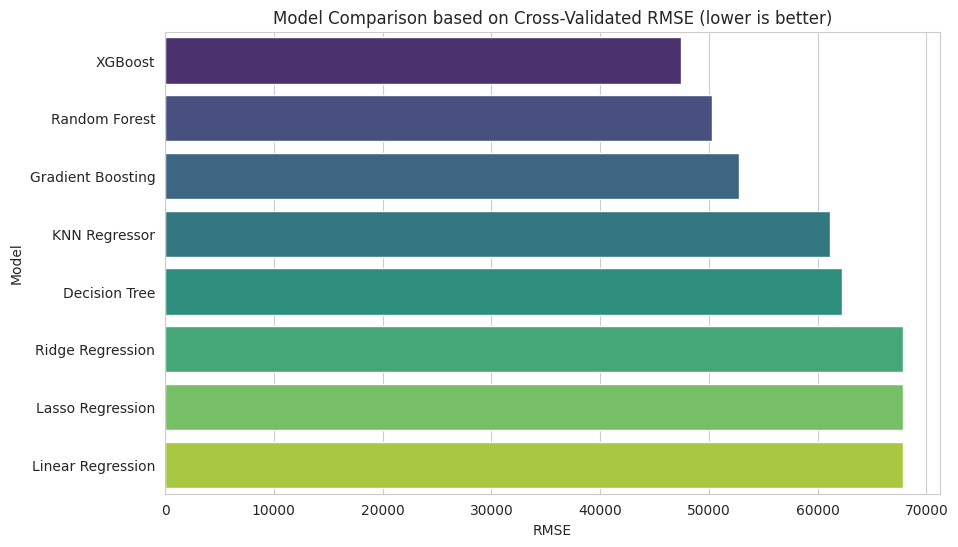


Best model based on cross validation: XGBoost


In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="RMSE (mean)", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison based on Cross-Validated RMSE (lower is better)")
plt.xlabel("RMSE")
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model based on cross validation: {best_model_name}")

## 7. Tune the best model (Hyperparameter Tuning)

From the comparison above, ensemble models (Random Forest, Gradient
Boosting, XGBoost) perform best, and XGBoost achieved the lowest RMSE
and highest R2 in cross validation. We use GridSearchCV to tune XGBoost
and find its best settings.

In [16]:
param_grid = {
    "n_estimators": [150, 300],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
}

xgb_model = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
Best CV RMSE: 46321.491633810794


## 8. Evaluate the final model on the test set

We use the test data that the model has never seen, evaluated with
RMSE, MAE, R2, and MAPE.

In [17]:
y_pred = best_model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("=" * 50)
print("Final Model Evaluation on Test Set")
print("=" * 50)
print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

Final Model Evaluation on Test Set
RMSE : 45,748.01
MAE  : 29,664.73
R2   : 0.8403
MAPE : 16.87%


### Actual vs Predicted

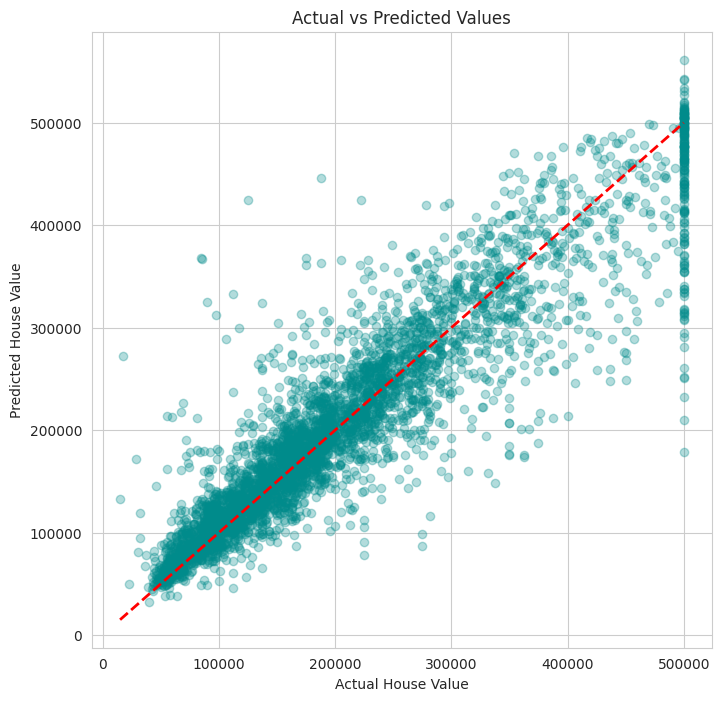

In [18]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color="darkcyan")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")
plt.show()

### Residuals plot

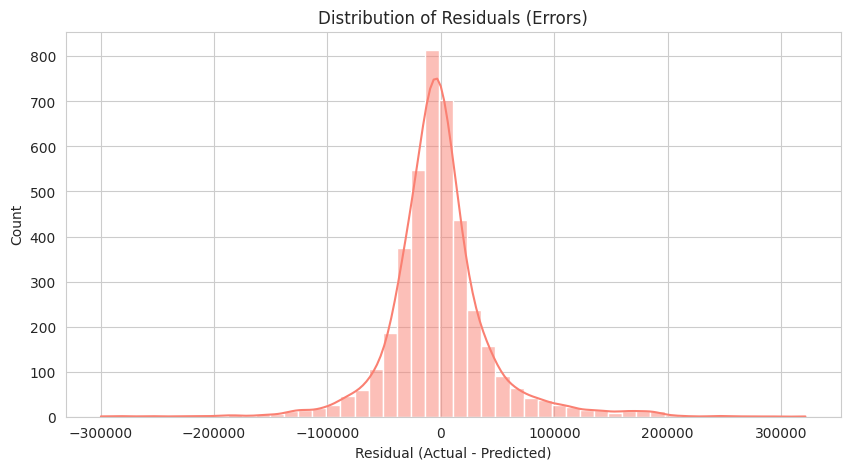

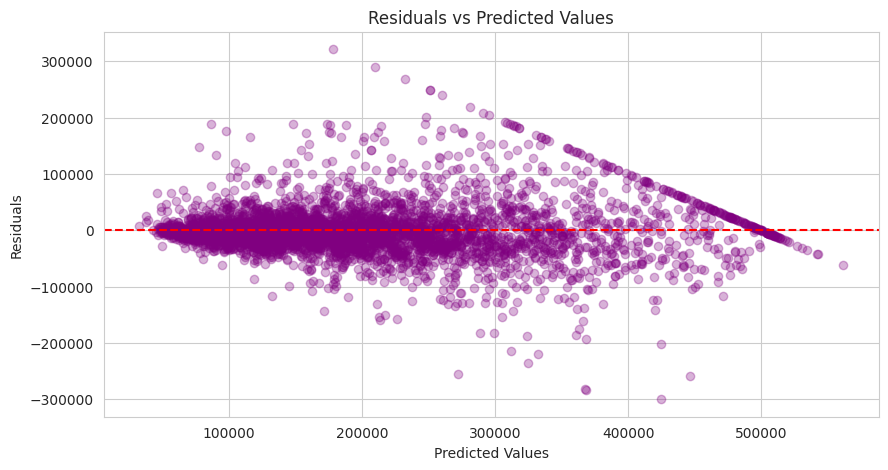

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True, color="salmon")
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color="purple")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

## 9. Feature importance

This shows which variables had the most influence on the model's predictions.

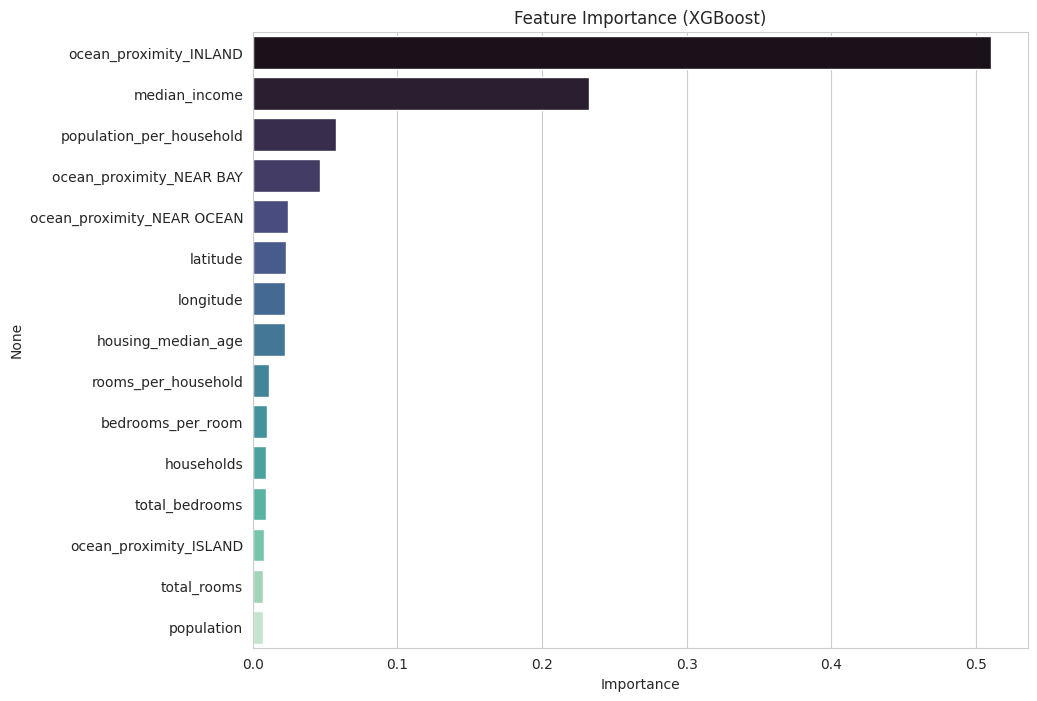

,0
ocean_proximity_INLAND,0.510511
median_income,0.232765
population_per_household,0.057479
ocean_proximity_NEAR BAY,0.046394
ocean_proximity_NEAR OCEAN,0.024239
latitude,0.023038
longitude,0.022515
housing_median_age,0.021967
rooms_per_household,0.011235
bedrooms_per_room,0.009646


In [20]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="mako", legend=False)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.show()

importances